1. **Proporcionar una breve descripción del proceso de decisión y/o problemática a estudiar y las preguntas a resolver.**

La industria de los videojuegos se caracteriza por una incertidumbre intrínseca, en la cual la innovación implica altos riesgos tanto de capital como de esfuerzo humano. De acuerdo con la World Intellectual Property Organization (2024), se trata de un sector multimillonario pero altamente competitivo y concentrado, lo que genera importantes barreras de entrada y eleva el riesgo para nuevos actores. En este contexto, el presente trabajo propone el uso de la analítica de datos como una herramienta estratégica que permita transformar la ambigüedad en decisiones informadas, con el objetivo de maximizar las probabilidades de éxito en el desarrollo de videojuegos. Para ello, se plantean las siguientes preguntas estratégicas orientadas al análisis de datos:


*   ¿Cómo ha evolucionado el éxito comercial de los diferentes géneros de videojuegos a lo largo de los años, y cuáles representan actualmente las oportunidades de mercado más viables? Serie de tiempo o area apilada.


*   ¿Existe una correlación significativa entre la calificación de un videojuego (rating) y su volumen de ventas globales, y cómo cambia esta dinámica dependiendo del género o la plataforma elegida? Graficos de dispersión, coeficientes de correlación y Boxplot.


*   ¿Qué conjunto de variables permite predecir con mayor precisión el desempeño de un videojuego en términos de ventas globales y rating dentro de una industria saturada? Modelos de regresion o arboles de decision.



2. **Describir el proceso de preprocesamiento de los datos.**

Para preprocesar los datos es necesario primero normalizar la variable 'nombre' que se refiere al nombre de los videojuegos y es mediante esta que se hara la unión de los dos dataframes de la entrega anterior. Luego es necesario hacer una identificación y clasificación de cada una de las variables para posteriormente hacer el debido preprocesamiento que cada una requiera como se muestra a continuación.

In [ ]:
import pandas as pd
import numpy as np
import re # La usamos para la organizacion de los nombres

## Descarga de DataFrames obtenidos en la entrega #2


file_id1 = '14hbTIQ7pFNeaxU6hq-41h0_KxTToBNGz' # Dataset IGBD
file_id2 = '1KYIfH-JjEwwAUMBu1IMw5Z5ClFPl-p5p' # Dataset VGChartz
df1 = pd.read_csv(f'https://docs.google.com/uc?export=download&id={file_id1}')
df2 = pd.read_csv(f'https://docs.google.com/uc?export=download&id={file_id2}')


In [ ]:
df1.head(3)


,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,rating_expertos,categoria_igdb
0,Grand Theft Auto V,"PlayStation 3, PlayStation 4, PC (Microsoft Wi...",2013.0,"Shooter, Racing, Adventure","Single player, Multiplayer, Co-operative","First person, Third person",89.61,5642,88.14,Juego Principal
1,The Witcher 3: Wild Hunt,"Xbox Series X|S, PlayStation 4, PC (Microsoft ...",2015.0,"Role-playing (RPG), Adventure",Single player,Third person,93.79,5206,91.73,Juego Principal
2,Portal 2,"PlayStation 3, Linux, PC (Microsoft Windows), ...",2011.0,"Platform, Puzzle, Adventure","Single player, Multiplayer, Co-operative, Spli...",First person,91.34,4282,92.44,Juego Principal


In [ ]:
df2.head(3)

,nombre,ventas_globales_millones
0,Tetris,520.00
1,Pokemon,505.15
2,Call of Duty,500.00


In [ ]:
# Continuamos normalizando la columna que contiene el nombre del videojuego para ambas bases de datos para de esta forma poder unirlas posteriormente.

def limpiar_titulos(texto):
    if pd.isna(texto):
        return ""
    else:
        texto = str(texto).lower() # 1. Convertir en minúsculas y en formato texto
        texto = re.sub(r'[^\w\s]', ' ', texto) # 2. Eliminar puntuación (dos puntos, guiones, comas, exclamaciones)
        texto = " ".join(texto.split()) # 3. Eliminar espacios extra
        return texto

df1['nombre'] = df1['nombre'].apply(limpiar_titulos)
df2['nombre'] = df2['nombre'].apply(limpiar_titulos)

In [ ]:
df1.head()

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,rating_expertos,categoria_igdb
0,grand theft auto v,"PlayStation 3, PlayStation 4, PC (Microsoft Wi...",2013.0,"Shooter, Racing, Adventure","Single player, Multiplayer, Co-operative","First person, Third person",89.61,5642,88.14,Juego Principal
1,the witcher 3 wild hunt,"Xbox Series X|S, PlayStation 4, PC (Microsoft ...",2015.0,"Role-playing (RPG), Adventure",Single player,Third person,93.79,5206,91.73,Juego Principal
2,portal 2,"PlayStation 3, Linux, PC (Microsoft Windows), ...",2011.0,"Platform, Puzzle, Adventure","Single player, Multiplayer, Co-operative, Spli...",First person,91.34,4282,92.44,Juego Principal
3,the elder scrolls v skyrim,"PlayStation 3, PC (Microsoft Windows), Xbox 360",2011.0,"Role-playing (RPG), Adventure",Single player,"First person, Third person",87.69,4173,79.92,Juego Principal
4,grand theft auto san andreas,"Xbox, PlayStation 3, PlayStation 4, Android, P...",2004.0,"Shooter, Racing, Adventure","Single player, Co-operative","First person, Third person",90.03,3867,93.14,Juego Principal


In [ ]:
df2.head()

,nombre,ventas_globales_millones
0,tetris,520.00
1,pokemon,505.15
2,call of duty,500.00
3,grand theft auto,465.00
4,super mario,432.79


## Unión de las bases de datos

In [ ]:
# Antes de unir las bases de datos es necesario unir todas las variables repetidas en el dataset 2 (VGChartz), para de esta forma tener una variable que represente
# todas las ventas globales de todas las plataformas


# Agrupamos por el nombre del juego y sumamos las ventas
df2 = df2.groupby('nombre', as_index=False).agg({
    'ventas_globales_millones': 'sum'
})

df2 = df2.sort_values(by='ventas_globales_millones', ascending=False)
df2 = df2.reset_index(drop=True)

df2.head()

,nombre,ventas_globales_millones
0,minecraft,700.00
1,tetris,560.58
2,pokemon,505.15
3,call of duty,504.50
4,grand theft auto,468.50


In [ ]:
# Esto es mas bien con fines de verificacion

resultado = df2[df2['nombre'] == 'fifa 19']
print(resultado)


      nombre  ventas_globales_millones
228  fifa 19                      20.0


In [ ]:
# Ahora utilizamos la opción del Merge de pandas para unir las bases de datos

df_unido = pd.merge(df1, df2, on='nombre', how='inner')
print(f"Se unieron {len(df_unido)} videojuegos.")

Se unieron 2454 videojuegos.


In [ ]:
df_unido.head()

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,rating_expertos,categoria_igdb,ventas_globales_millones
0,grand theft auto v,"PlayStation 3, PlayStation 4, PC (Microsoft Wi...",2013.0,"Shooter, Racing, Adventure","Single player, Multiplayer, Co-operative","First person, Third person",89.61,5642,88.14,Juego Principal,237.60
1,the witcher 3 wild hunt,"Xbox Series X|S, PlayStation 4, PC (Microsoft ...",2015.0,"Role-playing (RPG), Adventure",Single player,Third person,93.79,5206,91.73,Juego Principal,80.60
2,portal 2,"PlayStation 3, Linux, PC (Microsoft Windows), ...",2011.0,"Platform, Puzzle, Adventure","Single player, Multiplayer, Co-operative, Spli...",First person,91.34,4282,92.44,Juego Principal,13.06
3,the elder scrolls v skyrim,"PlayStation 3, PC (Microsoft Windows), Xbox 360",2011.0,"Role-playing (RPG), Adventure",Single player,"First person, Third person",87.69,4173,79.92,Juego Principal,60.00
4,grand theft auto san andreas,"Xbox, PlayStation 3, PlayStation 4, Android, P...",2004.0,"Shooter, Racing, Adventure","Single player, Co-operative","First person, Third person",90.03,3867,93.14,Juego Principal,44.80


## Identificación de datos Faltantes

Después de unir las bases de datos realizamos la identificación del tipo de variable que tenemos y los datos faltantes por cada una de estas.

In [ ]:
df_unido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2454 entries, 0 to 2453
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   nombre                    2454 non-null   object 
 1   plataformas               2454 non-null   object 
 2   año_lanzamiento           2454 non-null   float64
 3   generos                   2448 non-null   object 
 4   modos_juego               2448 non-null   object 
 5   perspectiva               2404 non-null   object 
 6   rating_usuarios           2454 non-null   float64
 7   votos_usuarios            2454 non-null   int64  
 8   rating_expertos           1895 non-null   float64
 9   categoria_igdb            2454 non-null   object 
 10  ventas_globales_millones  2454 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 211.0+ KB


El dataset cuenta con 2454 registros y presenta valores faltantes en algunas variables clave: 6 en géneros, 6 en modos de juego, 50 en perspectiva y 559 en rating de expertos. Aunque los datos faltantes en variables categóricas son mínimos y manejables, la alta cantidad de valores ausentes en el rating de expertos requiere un tratamiento cuidadoso para no afectar los análisis posteriores. Al realizar ciertas evaluaciones, se decidio eliminar la columna de `rating_expertos`.

La decisión de eliminar la variable `rating_expertos` se fundamenta en dos conclusiones:

*   El 22.7% de datos faltantes no ocurre al azar, sino que afecta desproporcionadamente a juegos independientes o de menor presupuesto. Eliminar los registros (filas) introduciría un sesgo de selección que limitaría la validez del modelo únicamente a títulos "AAA" (Little & Rubin, 2019; Heckman, 1979).

*   La literatura sobre comportamiento del consumidor demuestra que el "boca a boca" digital (eWOM) y las calificaciones de la comunidad (rating_usuarios) son predictores más precisos y robustos del éxito comercial a largo plazo que la evaluación inicial de la crítica especializada (Duan, Gu, & Whinston, 2008; Chevalier & Mayzlin, 2006).


In [ ]:
df_copy= df_unido.copy()

df_unido.drop(columns=['rating_expertos'], inplace=True)

In [ ]:
df_unido.head(2)

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones
0,grand theft auto v,"PlayStation 3, PlayStation 4, PC (Microsoft Wi...",2013.0,"Shooter, Racing, Adventure","Single player, Multiplayer, Co-operative","First person, Third person",89.61,5642,Juego Principal,237.6
1,the witcher 3 wild hunt,"Xbox Series X|S, PlayStation 4, PC (Microsoft ...",2015.0,"Role-playing (RPG), Adventure",Single player,Third person,93.79,5206,Juego Principal,80.6


##**Variables categóricas**

Como pudimos observar anteriormente, las variables categoricas que tenemos en nuestra base de datos son:

*   `plataformas, generos, modos_juego, perspectiva`


In [ ]:
df_unido[['plataformas', 'generos', 'modos_juego', 'perspectiva']].head()

,plataformas,generos,modos_juego,perspectiva
0,"PlayStation 3, PlayStation 4, PC (Microsoft Wi...","Shooter, Racing, Adventure","Single player, Multiplayer, Co-operative","First person, Third person"
1,"Xbox Series X|S, PlayStation 4, PC (Microsoft ...","Role-playing (RPG), Adventure",Single player,Third person
2,"PlayStation 3, Linux, PC (Microsoft Windows), ...","Platform, Puzzle, Adventure","Single player, Multiplayer, Co-operative, Spli...",First person
3,"PlayStation 3, PC (Microsoft Windows), Xbox 360","Role-playing (RPG), Adventure",Single player,"First person, Third person"
4,"Xbox, PlayStation 3, PlayStation 4, Android, P...","Shooter, Racing, Adventure","Single player, Co-operative","First person, Third person"


Inicialmente identificamos los valores faltantes correspondientes a cada variable

In [ ]:
df_unido[df_unido['generos'].isna()]

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones
1812,harry potter and the chamber of secrets,PlayStation,2002.0,NaN,Single player,Third person,70.51,26,Port,9.00
1900,gears of war,PC (Microsoft Windows),2007.0,NaN,NaN,Third person,79.08,23,Juego Expandido,41.00
2035,lego star wars ii the original trilogy,"Xbox, Nintendo GameCube, PlayStation 2",2006.0,NaN,"Single player, Multiplayer",Third person,80.26,19,Port,8.20
2335,monster hunter rise sunbreak,"Xbox Series X|S, PlayStation 4, PC (Microsoft ...",2022.0,NaN,"Single player, Multiplayer, Co-operative",NaN,87.41,12,Bundle,10.90
2417,monster hunter 4,Nintendo 3DS,2013.0,NaN,"Single player, Multiplayer",Third person,76.21,11,Juego Principal,12.40
2418,the fifth element,"PC (Microsoft Windows), PlayStation",1998.0,NaN,Single player,Third person,31.28,11,Juego Principal,0.75


Dado que la variable géneros presenta un solo 6 valores faltantes, y considerando que esta información es accesible a través de fuentes externas confiables, se opta por completar los datos de manera manual. Esto permite conservar los registros sin afectar el tamaño del dataset ni la calidad del análisis.

Las fuentes confiables son las siguientes:



*   https://www.igdb.com/games/harry-potter-and-the-chamber-of-secrets--5
*   https://www.igdb.com/games/gears-of-war
*   https://www.igdb.com/games/lego-star-wars-ii-the-original-trilogy--1
*   https://store.playstation.com/es-mx/product/UP0102-PPSA08033_00-SBSET00000000000
*   https://es.wikipedia.org/wiki/Monster_Hunter_4
*   https://fifth-element.fandom.com/wiki/The_Fifth_Element_(video_game)



In [ ]:
df_unido.loc[1812, 'generos'] = 'Adventure'
df_unido.loc[1900, 'generos'] = 'Shooter'
df_unido.loc[2035, 'generos'] = "Hack and slash/beat 'em up, Adventure"
df_unido.loc[2335, 'generos'] = 'Role-playing (RPG)'
df_unido.loc[2417, 'generos'] = 'Role-playing (RPG)'
df_unido.loc[2418, 'generos'] = 'Adventure'

Listo calisto, ya no hay nulos para esta variable

In [ ]:
df_unido[df_unido['generos'].isna()]

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones


In [ ]:
# Estandarización del texto
df_unido['generos'] = df_unido['generos'].str.lower().str.strip()
df_unido['generos'] = df_unido['generos'].str.replace(r'\s*,\s*', ',', regex=True)
df_generos = df_unido['generos'].str.get_dummies(sep=',')

In [ ]:
df_generos.sum()

,0
adventure,1269
arcade,223
card & board game,37
fighting,180
hack and slash/beat 'em up,230
indie,531
music,50
pinball,3
platform,435
point-and-click,87


Ahora seguimos con la variable `modos_juego`, segun la informacion anterior se presentaban 6 registros nulos. Para esto hacemos lo mismo que en los generos.


Las fuentes confiables son las siguientes:


*   https://www.igdb.com/games/soulcalibur-ii
*   https://www.igdb.com/games/wwe-smackdown-shut-your-mouth
*   https://www.igdb.com/games/gears-of-war
*   https://www.igdb.com/games/metal-slug-3
*   https://www.igdb.com/games/panzer-general-2
*   https://www.igdb.com/games/counter-strike

In [ ]:
df_unido[df_unido['modos_juego'].isna()]

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones
799,soulcalibur iii,PlayStation 2,2005.0,"fighting,strategy",NaN,Side view,79.78,129,Juego Principal,1.43
1263,wwe smackdown here comes the pain,PlayStation 2,2003.0,"sport,hack and slash/beat 'em up",NaN,"Third person, Bird view / Isometric, Side view",73.64,58,Juego Principal,2.00
1900,gears of war,PC (Microsoft Windows),2007.0,shooter,NaN,Third person,79.08,23,Juego Expandido,41.00
2075,metal slug 3,"Xbox, PlayStation 2",2003.0,"shooter,arcade",NaN,NaN,87.96,18,Port,0.65
2148,panzer general,"3DO Interactive Multiplayer, DOS, PlayStation",1994.0,strategy,NaN,NaN,93.53,17,Juego Principal,0.31
2398,counter strike,Xbox,2003.0,shooter,NaN,NaN,88.49,11,Port,70.70


In [ ]:
df_unido.loc[799, 'modos_juego'] = 'Single player, Multiplayer'
df_unido.loc[1263, 'modos_juego'] = 'Single player, Split screen'
df_unido.loc[1900, 'modos_juego'] = 'Single player, Multiplayer, Co-operative, Split screen'
df_unido.loc[2075, 'modos_juego'] = 'Single player, Multiplayer, Co-operative'
df_unido.loc[2148, 'modos_juego'] = 'Single player'
df_unido.loc[2398, 'modos_juego'] = 'Multiplayer'

Observamos el mismo resultado, ya no encontramos valores nulos en los modos de juego

In [ ]:
df_unido[df_unido['modos_juego'].isna()]

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones


In [ ]:
df_unido['modos_juego'] = df_unido['modos_juego'].str.lower().str.strip()
df_unido['modos_juego'] = df_unido['modos_juego'].str.replace(r'\s*,\s*', ',', regex=True)
df_modosjuego = df_unido['modos_juego'].str.get_dummies(sep=',')

In [ ]:
df_modosjuego.sum()

,0
battle royale,3
co-operative,603
massively multiplayer online (mmo),40
multiplayer,1185
single player,2413
split screen,278


Ahora identificaremos los registros nulos de la variable perspectiva.

In [ ]:
df_unido[df_unido['perspectiva'].isna()].head(5)

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones
1106,test drive unlimited 2,"PlayStation 3, PC (Microsoft Windows), Xbox 360",2011.0,racing,"single player,multiplayer,co-operative,massive...",NaN,69.04,78,Juego Principal,1.80
1172,football manager 2020,"Google Stadia, PC (Microsoft Windows), Mac",2019.0,"simulator,sport","single player,multiplayer",NaN,77.23,68,Juego Principal,3.00
1298,bejeweled 3,"PC (Microsoft Windows), Mac",2010.0,"puzzle,strategy,adventure",single player,NaN,75.44,55,Juego Principal,0.30
1361,the jackbox party pack 4,"Amazon Fire TV, PlayStation 4, Linux, Android,...",2017.0,"puzzle,strategy,quiz/trivia,indie","single player,multiplayer,co-operative",NaN,76.53,49,Juego Principal,0.12
1381,inazuma eleven,"Nintendo 3DS, Nintendo DS",2008.0,"role-playing (rpg),sport","single player,multiplayer",NaN,74.86,48,Juego Principal,8.80


In [ ]:
print(f"El porcentaje que representan estos registros faltantes es del {(50/2454*100):,.2f}%")

El porcentaje que representan estos registros faltantes es del 2.04%


Para el tratamiento de estos valores faltantes, se optó por un enfoque pragmático basado en el costo-beneficio analítico y la segmentación por valor (Provost & Fawcett, 2013). Se estableció un umbral de 5 millones en la variable `ventas_globales_millones` para dividir el dataset en dos segmentos con tratamientos de datos diferenciados:

*   Para los títulos que superan el umbral, la integridad del dato es crítica para el análisis estratégico. Basado en los principios de Gestión de Calidad de Datos (Redman, 2001), se asume que los datos faltantes en este segmento de alto valor son anomalías corregibles (MCAR), justificando la inversión de tiempo en una imputación manual.

*   Para los títulos por debajo del umbral, que representan la "larga estela" de la industria (Anderson, 2006), los datos faltantes (MNAR) reflejan una falta de cobertura real en el mercado. En este grupo, se aplicó la eliminación de registros para evitar la invención de datos en nichos de baja representatividad comercial.

In [ ]:
umbral = 5 # Umbral de millones
df_umbral = df_unido[df_unido['ventas_globales_millones'] >= umbral]

df_umbral[df_umbral['perspectiva'].isna()]

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones
1381,inazuma eleven,"Nintendo 3DS, Nintendo DS",2008.0,"role-playing (rpg),sport","single player,multiplayer",NaN,74.86,48,Juego Principal,8.80
1869,need for speed most wanted,Legacy Mobile Device,2005.0,racing,single player,NaN,83.93,24,Port,17.80
1932,just dance 3,"PlayStation 3, Xbox 360",2011.0,music,"single player,multiplayer,split screen",NaN,72.51,23,Juego Principal,17.00
2065,just dance,Wii,2009.0,music,"single player,split screen",NaN,59.97,19,Juego Principal,86.00
2101,monster rancher,PlayStation,1997.0,"role-playing (rpg),simulator,strategy","single player,multiplayer",NaN,74.22,18,Juego Principal,5.04
2119,tetris,"BlackBerry OS, PlayStation 3, Windows Phone, A...",2009.0,"puzzle,strategy",single player,NaN,72.46,17,Remake,560.58
2335,monster hunter rise sunbreak,"Xbox Series X|S, PlayStation 4, PC (Microsoft ...",2022.0,role-playing (rpg),"single player,multiplayer,co-operative",NaN,87.41,12,Bundle,10.90
2398,counter strike,Xbox,2003.0,shooter,multiplayer,NaN,88.49,11,Port,70.70


Las fuentes confiables son las siguientes:


*   https://inazuma.fandom.com/es/wiki/Inazuma_Eleven_(franquicia)
*   https://www.igdb.com/games/need-for-speed-most-wanted-53b9fef3-adb4-41a0-8ca0-ffcbb0060467
*   https://es.wikipedia.org/wiki/Just_Dance_(videojuego)
*   https://es.wikipedia.org/wiki/Just_Dance_(videojuego)
*   https://www.igdb.com/games/monster-rancher-2
*   https://www.igdb.com/games/tetris--1
*   https://www.igdb.com/games/monster-hunter-rise-sunbreak
*   https://www.igdb.com/games/counter-strike


In [ ]:
df_unido.loc[1381, 'perspectiva'] = 'First person, Third person, Bird view / Isometric'
df_unido.loc[1869, 'perspectiva'] = 'First person, Third person'
df_unido.loc[1932, 'perspectiva'] = 'Third person'
df_unido.loc[2065, 'perspectiva'] = 'Third person'
df_unido.loc[2101, 'perspectiva'] = 'First person, Side view'
df_unido.loc[2119, 'perspectiva'] = 'Side view'
df_unido.loc[2335, 'perspectiva'] = 'Third person'
df_unido.loc[2398, 'perspectiva'] = 'First person'

Una vez identificados estos datos que superaban el umbral de 5 millones, se eliminaron los otros valores faltantes que no superaban el umbral en la base de datos.

In [ ]:
df_unido = df_unido.dropna(subset=['perspectiva'])

# Reseteamos el índice
df_unido = df_unido.reset_index(drop=True)

In [ ]:
df_unido[df_unido['perspectiva'].isna()]

,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones


In [ ]:
df_unido['perspectiva'] = df_unido['perspectiva'].str.lower().str.strip()
df_unido['perspectiva'] = df_unido['perspectiva'].str.replace(r'\s*,\s*', ',', regex=True)
df_perspectiva = df_unido['perspectiva'].str.get_dummies(sep=',')

In [ ]:
df_perspectiva.sum()

,0
auditory,20
bird view / isometric,581
first person,527
side view,612
text,63
third person,1082
virtual reality,34


## Identificación de datos duplicados

Con el siguiente codigo identificaremos la presencia de datos duplicados a nivel general dentro de nuestro conjunto de datos.

In [ ]:
duplicados1 = df_unido.duplicated()

# Imprimir las filas duplicadas
duplicados1

conteo_duplicados= 0

for i in duplicados1:
    if i == False:
        continue
    else:
        conteo_duplicados += 1

conteo_duplicados

0

In [ ]:
duplicados_nombres = df_unido.duplicated(subset=['nombre']).sum()
print(f"\nNombres duplicados (filas diferentes para el mismo juego): {duplicados_nombres}")

if duplicados_nombres > 0:
    df_nombres_repetidos = df_unido[df_unido.duplicated(subset=['nombre'], keep=False)]
    df_nombres_repetidos = df_nombres_repetidos.sort_values(by='nombre')

    display(df_nombres_repetidos.head(10))


Nombres duplicados (filas diferentes para el mismo juego): 239


,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones
2137,1942,"Family Computer, Nintendo Entertainment System",1985.0,shooter,"single player,multiplayer",bird view / isometric,61.39,16,Port,1.4
995,1942,"Arcade, PC-8800 Series, PlayStation 3, Commodo...",1984.0,"shooter,arcade","single player,co-operative",bird view / isometric,67.74,95,Juego Principal,1.4
1084,alone in the dark,"Acorn Archimedes, PC-9800 Series, PC (Microsof...",1992.0,"puzzle,adventure",single player,third person,72.46,81,Juego Principal,2.5
1395,alone in the dark,"Xbox Series X|S, PC (Microsoft Windows), PlayS...",2024.0,"puzzle,adventure",single player,third person,72.81,47,Remake,2.5
1019,alone in the dark,"PC (Microsoft Windows), Xbox 360",2008.0,"shooter,puzzle,adventure",single player,"first person,third person",57.57,91,Juego Principal,2.5
1504,assassin s creed brotherhood,"PlayStation 4, Xbox One, Nintendo Switch",2016.0,adventure,single player,third person,90.01,40,Remaster,7.2
44,assassin s creed brotherhood,"PlayStation 3, PC (Microsoft Windows), Mac, Xb...",2010.0,"puzzle,adventure","single player,multiplayer",third person,82.76,1703,Juego Principal,7.2
11,assassin s creed ii,"PlayStation 3, PC (Microsoft Windows), Mac, Xb...",2009.0,"platform,adventure",single player,third person,86.67,3099,Juego Principal,9.0
1754,assassin s creed ii,"PlayStation 4, Xbox One, Nintendo Switch",2016.0,"platform,adventure",single player,third person,72.55,28,Remaster,9.0
82,assassin s creed revelations,"PlayStation 3, PC (Microsoft Windows), Xbox 360",2011.0,adventure,"single player,multiplayer",third person,76.91,1211,Juego Principal,7.0


Como se puede observar, hay juegos repetido en la base de datos, esto se explica con que los juegos tienen categorias diferentes asi como juego principal y remake. Ademas estos son lanzados en diferentes años.

Teniendo eso en cuenta realizamos otro filtro para identificar los datos duplicados.

In [ ]:
duplicados3 = df_unido.duplicated(subset=['nombre', 'año_lanzamiento', 'categoria_igdb']).sum()
print(f"\nDuplicados reales (mismo nombre, año y categoría): {duplicados3}")

if duplicados3 > 0:
    df_duplicados3 = df_unido[df_unido.duplicated(subset=['nombre', 'año_lanzamiento', 'categoria_igdb'], keep=False)]
    df_duplicados3 = df_duplicados3.sort_values(by='nombre')

df_duplicados3.head(5)


Duplicados reales (mismo nombre, año y categoría): 17


,nombre,plataformas,año_lanzamiento,generos,modos_juego,perspectiva,rating_usuarios,votos_usuarios,categoria_igdb,ventas_globales_millones
611,disney s aladdin,"Super Nintendo Entertainment System, PC (Micro...",1993.0,"platform,adventure,arcade",single player,side view,80.90,191,Juego Principal,5.75
636,disney s aladdin,"Linux, Sega Mega Drive/Genesis, PC (Microsoft ...",1993.0,platform,single player,side view,80.92,184,Juego Principal,5.75
2183,harry potter and the chamber of secrets,Game Boy Color,2002.0,"role-playing (rpg),adventure",single player,"bird view / isometric,side view",60.53,15,Port,9.00
1801,harry potter and the chamber of secrets,PlayStation,2002.0,adventure,single player,third person,70.51,26,Port,9.00
1755,harry potter and the chamber of secrets,PlayStation 2,2002.0,adventure,single player,third person,74.53,28,Port,9.00


En vista de que en los juegos que aparecen hay algunos muy iconicos, se decidio corregir estos datos con algunas reglas logicas.

In [ ]:
def unir_unicos(serie):
    elementos = set()
    for item in serie.dropna().astype(str):
        for sub_item in item.split(','):
            elementos.add(sub_item.strip())
    return ', '.join(sorted(elementos)) if elementos else np.nan

def string_mas_largo(serie):
    validos = serie.dropna().astype(str)
    if validos.empty:
        return np.nan
    return max(validos, key=len)

reglas_agregacion = {
    'plataformas': unir_unicos,
    'generos': unir_unicos,
    'modos_juego': string_mas_largo,
    'perspectiva': string_mas_largo,
    'rating_usuarios': 'max',
    'votos_usuarios': 'max',
    'ventas_globales_millones': 'max'
}

# Agrupamos los duplicados y los fusionamos
df_unido = df_unido.groupby(
    ['nombre', 'año_lanzamiento', 'categoria_igdb'],
    as_index=False
).agg(reglas_agregacion)


# Verificacion

duplicados3 = df_unido.duplicated(subset=['nombre', 'año_lanzamiento', 'categoria_igdb']).sum()
print(f"Cantidad de duplicados con el mismo nombre, año y categoría: {duplicados3}")

if duplicados3 > 0:
    df_duplicados3 = df_unido[df_unido.duplicated(subset=['nombre', 'año_lanzamiento', 'categoria_igdb'], keep=False)]
    df_duplicados3 = df_duplicados3.sort_values(by='nombre')
    display(df_duplicados3.head(5))
else:
    print("No hay mas duplicados")

Cantidad de duplicados con el mismo nombre, año y categoría: 0
No hay mas duplicados


Con estas reglas para corregir esos valores duplicados, se conservo la información para futuros análisis y se eliminaron los duplicados. Very well

## Identificación de datos atípicos

**Estrategias basadas en visualización**

Una primera estrategia de análisis para la identificación de datos atípicos es a través de la visualización de los datos.  En este caso discutiremos 2 tipos de visualizaciones que son de utilidad:
* Histogramas
* Diagramas de caja y bigote (boxplots)


## <font color='8EC044'> **Histogramas** </font>

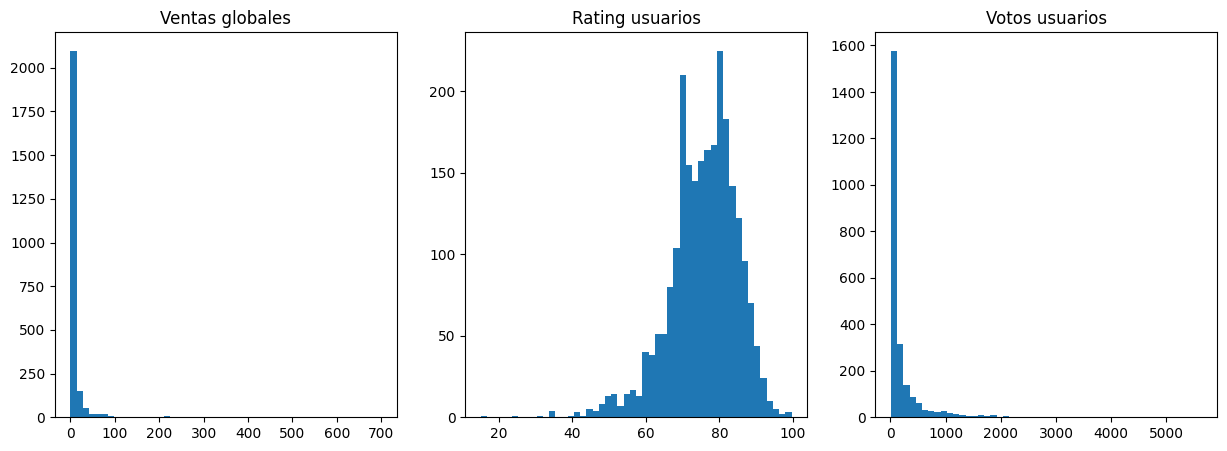

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15,5))

# Histograma 1
ax[0].hist(df_unido['ventas_globales_millones'], bins=50)
ax[0].set_title('Ventas globales')

# Histograma 2
ax[1].hist(df_unido['rating_usuarios'], bins=50)
ax[1].set_title('Rating usuarios')

# Histograma 3
ax[2].hist(df_unido['votos_usuarios'], bins=50)
ax[2].set_title('Votos usuarios')

plt.show()

A partir del análisis del ***histograma de ventas globales***, se concluye que el mercado analizado presenta una estructura de alta concentración y desigualdad. La distribución de los datos no sigue una curva normal, sino que se define por una asimetría positiva extrema, donde la gran mayoría de los registros se sitúan en rangos de ventas bajos (inferiores a los 20 millones).

El ***histograma de rating_usuarios*** muestra que la mayoría de los videojuegos tienen una recepción positiva, con calificaciones concentradas principalmente entre los 70 y 85 puntos. La gráfica presenta un claro sesgo hacia valores altos, lo que indica que las puntuaciones bajas son poco frecuentes y que la tendencia general de los jugadores es valorar los títulos de forma favorable, destacando dos picos de frecuencia cerca de los 70 y 80 puntos.


El ***histograma de votos_usuarios*** muestra una distribución con un marcado sesgo a la derecha, donde la gran mayoría de los videojuegos reciben una cantidad baja de votos (menos de 500). Esto indica que solo una pequeña minoría de títulos logra una alta participación de la comunidad, alcanzando miles de votos, mientras que la mayor parte del catálogo tiene una interacción mucho más limitada

## <font color='8EC044'> **Boxplots** </font>

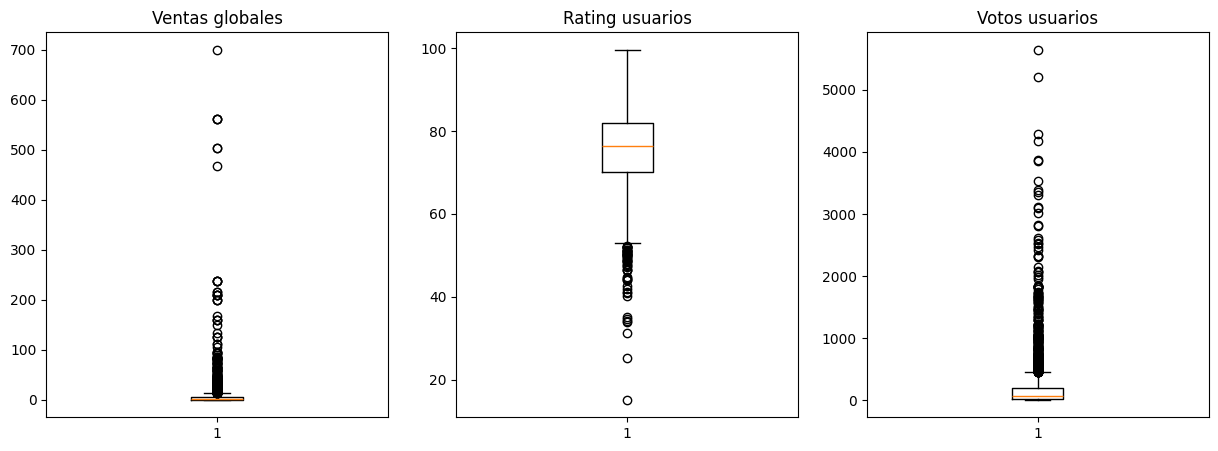

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15,5))

# Boxplot 1
ax[0].boxplot(df_unido['ventas_globales_millones'])
ax[0].set_title('Ventas globales')

# Boxplot 2
ax[1].boxplot(df_unido['rating_usuarios'])
ax[1].set_title('Rating usuarios')

# Boxplot 3
ax[2].boxplot(df_unido['votos_usuarios'])
ax[2].set_title('Votos usuarios')

plt.show()

***El boxplot de ventas globales*** confirma que el mercado de videojuegos está extremadamente concentrado. La gran mayoría de los títulos se ubican en la parte baja de la gráfica, con ventas que no suelen superar los 5.7 millones, mientras que los puntos aislados representan "superéxitos" excepcionales que alcanzan hasta los 700 millones.

***El boxplot de rating_usuarios*** confirma que la mayoría de los videojuegos tienen una buena valoración, con la mitad de los títulos concentrados entre los 70 y 82 puntos. A diferencia de las ventas, los valores atípicos aquí están por debajo de los 53 puntos es decir de la agrupación de los valores más comunes, lo que indica que es poco usual encontrar juegos con calificaciones muy bajas. La mediana de 76.4 refuerza que la percepción general de los usuarios es positiva, situando el estándar de calidad percibida bastante alto.


***El boxplot de votos_usuarios*** muestra que la gran mayoría de los videojuegos tienen una participación muy baja, con una mediana de apenas 64 votos. El hecho de que el "límite superior" esté en 444 indica que cualquier juego con más votos es una excepción; de hecho, los puntos que llegan hasta los 5642 votos representan títulos con una popularidad masiva fuera de lo normal. En conclusión, la interacción del público es sumamente desigual, concentrándose el interés en un grupo muy reducido de juegos.

## <font color='8EC044'> **Rango intercuartlico** </font>

###  Analisis ventas_globales_millones

Identifiquemos los datos atípicos para la variable ventas globales`ventas_globales_millones` con base en el indicador del rango intrcuartílico `RIQ`.

In [ ]:
# Calcular cuartiles
Q1 = df_unido['ventas_globales_millones'].quantile(0.25)
Q3 = df_unido['ventas_globales_millones'].quantile(0.75)

# Rango intercuartílico
ric = Q3 - Q1

# Límites (más estrictos: 3*IQR)
inferior = Q1 - (1.5* ric)
superior = Q3 + (1.5* ric)

# Detectar outliers
outliers_ventas = df_unido[
    (df_unido['ventas_globales_millones'] < inferior) |
    (df_unido['ventas_globales_millones'] > superior)
]

outliers_ventas[['nombre', 'ventas_globales_millones']].head()





,nombre,ventas_globales_millones
9,7 days to die,24.18
15,a way out,26.00
30,age of empires,33.82
40,alan wake,13.20
63,animal crossing,86.50


Se aplicó el método del rango intercuartílico (IQR) con un factor de 1.5 para la identificación de valores atípicos en la variable ventas_globales_millones.

Los resultados evidencian la presencia de videojuegos con niveles de ventas significativamente superiores al resto, como Grand Theft Auto V y The Witcher 3.

Estos valores atípicos no corresponden a errores en los datos, sino que reflejan la naturaleza del mercado de videojuegos, caracterizado por una alta concentración de ventas en pocos títulos exitosos.

Este comportamiento indica una distribución sesgada hacia la derecha, donde la mayoría de los videojuegos presentan ventas bajas o moderadas, mientras que un reducido grupo alcanza cifras excepcionalmente altas.

**Tratamiento datos atipicos**

Los valores atípicos identificados corresponden a videojuegos altamente exitosos, por lo que no se consideran errores sino observaciones relevantes. En consecuencia, no se realizó eliminación ni acotación de estos valores.

###  Analisis ranting_usuarios

Identifiquemos los datos atípicos para la variable ventas globales`rating_usuarios` con base en el indicador del rango intrcuartílico `RIQ`.

In [ ]:
# Calcular cuartiles
Q1 = df_unido['rating_usuarios'].quantile(0.25)
Q3 = df_unido['rating_usuarios'].quantile(0.75)

# Rango intercuartílico
ric = Q3 - Q1

# Límites (más estrictos: 3*IQR)
inferior = Q1 - (1.5* ric)
superior = Q3 + (1.5* ric)

# Detectar outliers
outliers_ventas = df_unido[
  (df_unido['rating_usuarios'] < inferior) |

  (df_unido['rating_usuarios'] > superior)

]

outliers_ventas[['nombre', 'rating_usuarios']].head()



,nombre,rating_usuarios
0,1 2 switch,49.68
37,agony,47.48
47,aliens colonial marines,47.20
135,battle stadium d o n,50.52
171,big pharma,43.93


Se aplicó el método del rango intercuartílico (IQR) para la detección de valores atípicos en la variable rating_usuarios. Los resultados evidencian la presencia de observaciones que se alejan del comportamiento central de los datos.
La existencia de estos valores atípicos sugiere una distribución con alta dispersión y posibles asimetrías, lo que indica que algunos videojuegos presentan valoraciones significativamente diferentes al promedio.

En consecuencia, estos valores fueron conservados, ya que aportan información relevante sobre la heterogeneidad en las evaluaciones de los usuarios.

**Tratamiento de datos atípicos**

Los valores atípicos identificados en la variable `rating_usuarios` no fueron modificados, ya que corresponden a observaciones válidas que reflejan la variabilidad en la percepción de los usuarios. Su conservación permite mantener la representatividad del comportamiento real de los datos.

###  Analisis votos_usuarios

Identifiquemos los datos atípicos para la variable ventas globales `votos_usuarios` con base en el indicador del rango intrcuartílico `RIQ`.

In [ ]:
# Calcular cuartiles
Q1 = df_unido['votos_usuarios'].quantile(0.25)
Q3 = df_unido['votos_usuarios'].quantile(0.75)

# Rango intercuartílico
ric = Q3 - Q1

# Límites (más estrictos: 3*IQR)
inferior = Q1 - (1.5* ric)
superior = Q3 + (1.5* ric)

# Detectar outliers
outliers_ventas = df_unido[
  (df_unido['votos_usuarios'] < inferior) |

  (df_unido['votos_usuarios'] > superior)

]

outliers_ventas[['nombre', 'votos_usuarios']].head()



,nombre,votos_usuarios
13,a plague tale innocence,757
15,a way out,634
30,age of empires,670
31,age of empires ii the age of kings,1006
33,age of mythology,460


Se realizó la identificación de valores atípicos en la variable votos_usuarios utilizando el método del rango intercuartílico (IQR). Los resultados evidencian la presencia de videojuegos con una cantidad de votos significativamente superior al resto del conjunto de datos.

Entre estos valores destacan títulos como Grand Theft Auto V, The Witcher 3: Wild Hunt, Portal 2 y The Elder Scrolls V: Skyrim, los cuales concentran miles de votos de usuarios. Estos valores atípicos no corresponden a errores en los datos, sino que reflejan altos niveles de popularidad, visibilidad y participación por parte de la comunidad de jugadores.

La presencia de estos valores indica que la distribución de la variable es asimétrica, donde la mayoría de los videojuegos cuenta con un número relativamente bajo de votos, mientras que un grupo reducido concentra una gran cantidad de interacciones. Este comportamiento es característico de mercados digitales, en los cuales pocos productos logran captar la mayor atención del público.

**Tratamiento de datos atípicos**

En consecuencia a todo lo anterior, los valores atípicos identificados fueron conservados en el análisis, ya que representan información relevante sobre el nivel de engagement de los usuarios y permiten comprender mejor la dinámica del mercado de videojuegos.

## Normalización y estandarización de los datos

En esta etapa se aplican procesos de codificación, normalización y estandarización de variables con el fin de preparar adecuadamente los datos para su análisis.

Por un lado, las variables cualitativas (como género, modo de juego o perspectiva) no pueden ser interpretadas directamente por modelos matemáticos o algoritmos, ya que estos trabajan con valores numéricos. Por ello, se transforman mediante técnicas como one-hot encoding, donde cada categoría se representa con valores binarios (0 y 1). Esto permite que la información categórica sea procesada sin introducir relaciones artificiales entre las categorías.

Por otro lado, las variables cuantitativas pueden presentar escalas muy diferentes (por ejemplo, ventas en millones frente a calificaciones en una escala de 1 a 10). Si no se ajustan, aquellas con valores más grandes pueden dominar el análisis o influir desproporcionadamente en modelos como clustering o regresión. Para evitar esto, se aplican procesos de normalización o estandarización, que permiten llevar todas las variables a una escala comparable.

En conjunto, estos procedimientos no solo nos facilitan la visualización de los datos, sino que garantizan un análisis más equilibrado, preciso y confiable al momento de extraer información relevante sobre los videojuegos.

# Referencias

Anderson, C. (2006). The Long Tail: Why the Future of Business is Selling Less of More. Hyperion.

Provost, F., & Fawcett, T. (2013). Data Science for Business: What you need to know about data mining and data-analytic thinking. O'Reilly Media.

Redman, T. C. (2001). Data Quality: The Field Guide. Digital Press.